<class 'pandas.core.frame.DataFrame'>
Index: 478 entries, 0 to 599
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             478 non-null    object 
 1   year               478 non-null    int64  
 2   income_per_capita  478 non-null    float64
 3   real_income        478 non-null    float64
 4   nominal_wage       478 non-null    float64
 5   real_wage          478 non-null    float64
 6   region_standard    478 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 29.9+ KB
None

Missing values by column:
 region               0
year                 0
income_per_capita    0
real_income          0
nominal_wage         0
real_wage            0
region_standard      0
dtype: int64

Number of unique regions: 80
Number of unique years: 6

Summary statistics:
        income_per_capita  real_income   nominal_wage   real_wage
count         478.000000   478.000000     478.000000  47

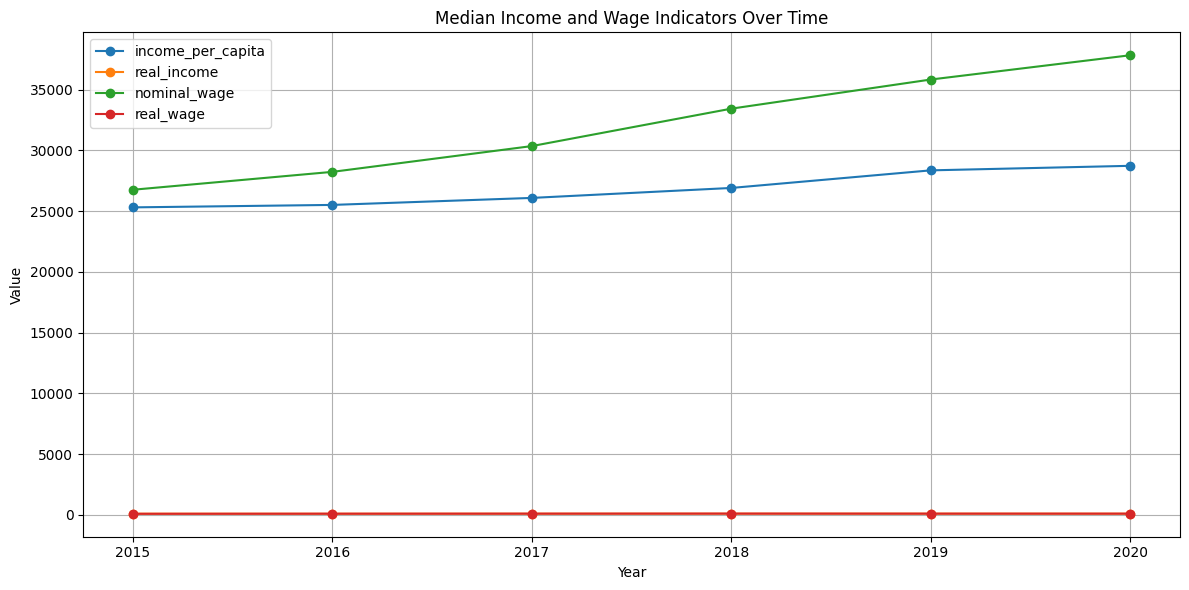

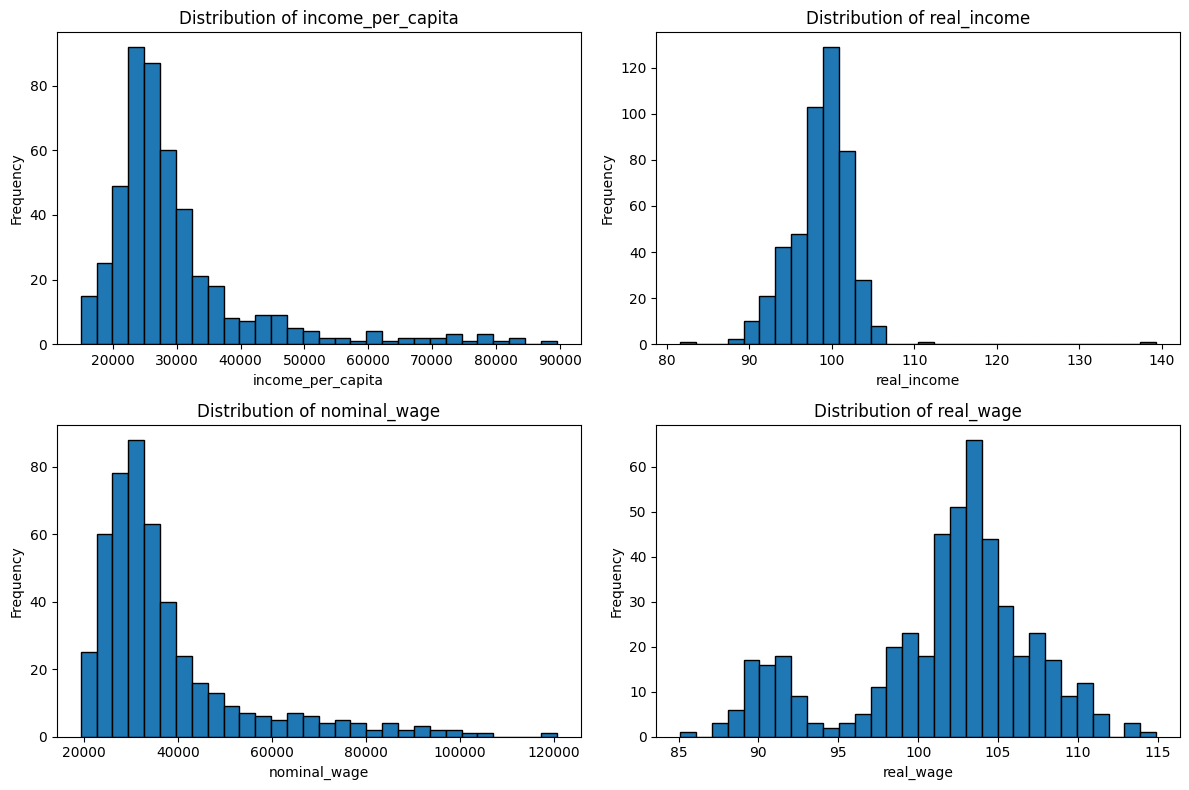

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/real_income_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()]

# 3. Ensure correct data type for real_wage
df["real_wage"] = pd.to_numeric(df["real_wage"], errors="coerce")

# 4. Remove rows with missing values in key columns
df = df.dropna(subset=["real_income", "income_per_capita", "nominal_wage", "real_wage"])

# 5. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 6. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 7. Summary statistics for income and wages
print("\nSummary statistics:\n", df[["income_per_capita", "real_income", "nominal_wage", "real_wage"]].describe())

# 8. Check duplicates
duplicates = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)

# 9. Top-5 regions by real income
top5 = df.sort_values(by="real_income", ascending=False).head(5)
print("\nTop-5 by real_income:\n", top5[["region_standard", "year", "real_income"]])

# 10. Median values by year
median_all = df.groupby("year")[["income_per_capita", "real_income", "nominal_wage", "real_wage"]].median()

# 11. Plot median trends
plt.figure(figsize=(12,6))
for col in median_all.columns:
    plt.plot(median_all.index, median_all[col], marker="o", label=col)

plt.title("Median Income and Wage Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Histograms for each variable
plt.figure(figsize=(12,8))
for i, col in enumerate(median_all.columns):
    plt.subplot(2,2,i+1)
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# EDA of `real_income_standardized.csv`

## Data Description
- The dataset contains 478 observations across 80 regions.
- Time coverage: 2015–2020.
- Key variables: income and wage indicators.

---

## Data Types
- All variables are correctly formatted.
- `real_wage` was converted to float.

---

## Missing Values
- No missing values remain after preprocessing (2 rows were removed).

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- **Income per capita:** median ~26,620 RUB  
- **Real income index:** median ~99.1%  
- **Nominal wage:** median ~32,283 RUB  
- **Real wage index:** median ~102.8%  

These values indicate moderate income levels with relatively stable real (inflation-adjusted) indicators.

---

## Trends
- Nominal indicators (income and wages) show gradual growth over time.  
- Real indicators remain relatively stable in the range of ~95–105%, reflecting the impact of inflation.  

This suggests that while nominal incomes increase, real purchasing power changes more slowly.

---

## Top-5 Regions by Real Income
1. Sevastopol (139.3%)  
2. Republic of Tuva (110.9%)  
3. Republic of Crimea (106.4%)  
4. Nenets Autonomous Okrug (105.9%)  
5. Republic of Crimea (105.9%)  

These regions exhibit higher-than-average growth in real income, indicating uneven economic dynamics across regions.

---

## Conclusion
The dataset is clean, consistent, and suitable for further analysis.

The observed variation in income and wage indicators across regions suggests that economic differences are significant and should contribute meaningfully to clustering results in the next stage of the analysis.

In [2]:
df.to_csv("../../data/clean/income_AfterEDA.csv", index=False)